In [2]:
import numpy as np
import matplotlib.pyplot as plt
from microboone_utils import *
import pandas as pd
import plotly.express as px
from file import File
from math import floor, ceil
import h5py

In [6]:
def save_planetruth_all(evts, out_path, plane=2, index_dtype=np.uint32, val_dtype=np.float32, compression="gzip", compression_opts=4):
    """Process a batch of events and append sparse coords/values to out_path HDF5.
    If the file does not exist, it is created. Coordinates are stored relative to each event's bbox."""
    coords_chunks = []
    values_chunks = []
    bboxes = []
    offsets = [0]
    event_idxs = []
    total = 0

    shape = (nwires(plane), ntimeticks())
    nrms = 2

    for ie, evt in enumerate(evts):
        evthits = evt['hit_table']
        evtdeps = evt['edep_table']
        evtparts = evt['particle_table']
        evtwires = evt['wire_table']

        try:
            evtdeps = evtdeps.sort_values(by=['energy_fraction'], ascending=False, kind='mergesort').drop_duplicates(["hit_id"])
            evth = evthits.merge(evtdeps, on=["hit_id"], how="left")
            evth = evth.merge(evtparts[['g4_id','category','instance']], on="g4_id", how="left")
        except Exception:
            evth = evthits.copy()

        evth['g4_id'] = evth['g4_id'].fillna(-1)
        evth = evth.fillna(0)

        planeadcs = evtwires.query("local_plane==%i"%plane)[['adc_%i'%i for i in range(0,ntimeticks())]].to_numpy()

        pt_mask = np.zeros(shape, dtype=np.uint8)
        nuhits = evth.query('local_plane==%i and g4_id>=0'%plane)[['local_wire','local_time','rms']]
        if nuhits.shape[0] == 0:
            continue

        for _, h in nuhits.iterrows():
            w = int(h['local_wire'])
            t0 = floor(h['local_time'] - nrms * h['rms'])
            t1 = ceil(h['local_time'] + nrms * h['rms'])
            t0 = max(0, t0)
            t1 = min(shape[1], t1)
            if t1>t0 and 0<=w<shape[0]:
                pt_mask[w, t0:t1] = 1

        cosmhits = evth.query('local_plane==%i and (g4_id<0 or category==7)'%plane)[['local_wire','local_time','rms']]
        for _, h in cosmhits.iterrows():
            w = int(h['local_wire'])
            t0 = floor(h['local_time'] - nrms * h['rms'])
            t1 = ceil(h['local_time'] + nrms * h['rms'])
            t0 = max(0, t0)
            t1 = min(shape[1], t1)
            if t1>t0 and 0<=w<shape[0]:
                pt_mask[w, t0:t1] = 0

        pt = np.multiply(pt_mask, planeadcs)
        if not np.any(pt):
            continue

        min_wire = int(nuhits['local_wire'].min())
        max_wire = int(nuhits['local_wire'].max())
        min_time = floor(nuhits['local_time'].min())
        max_time = ceil(nuhits['local_time'].max())

        w0, w1 = max(0, min_wire), min(shape[0], max_wire+1)
        t0, t1 = max(0, min_time), min(shape[1], max_time+1)
        cropped = pt[w0:w1, t0:t1]
        nz = np.nonzero(cropped)
        if nz[0].size == 0:
            continue

        coords_rel = np.vstack(nz).T.astype(index_dtype)
        vals = cropped[nz].astype(val_dtype)

        coords_chunks.append(coords_rel)
        values_chunks.append(vals)
        bboxes.append((w0, w1-1, t0, t1-1))
        event_idxs.append(ie)

        total += coords_rel.shape[0]
        offsets.append(total)

    if len(coords_chunks) == 0:
        return

    coords_batch = np.vstack(coords_chunks)
    values_batch = np.concatenate(values_chunks)
    offsets_batch = offsets

    with h5py.File(out_path, 'a') as hf:
        if 'coords' not in hf:
            maxshape_coords = (None, 2)
            hf.create_dataset('coords', data=coords_batch, maxshape=maxshape_coords, compression=compression, compression_opts=compression_opts)
            hf.create_dataset('values', data=values_batch, maxshape=(None,), compression=compression, compression_opts=compression_opts)
            hf.create_dataset('offsets', data=np.array(offsets_batch, dtype=np.int64), maxshape=(None,))
            hf.create_dataset('bboxes', data=np.array(bboxes, dtype=np.int32), maxshape=(None,4))
            hf.create_dataset('event_index', data=np.array(event_idxs, dtype=np.int32), maxshape=(None,))
            hf.attrs['planetruth_shape'] = shape
        else:
            cds = hf['coords']
            vds = hf['values']
            ods = hf['offsets']
            bds = hf['bboxes']
            eds = hf['event_index']

            n_old = cds.shape[0]
            cds.resize((n_old + coords_batch.shape[0], 2))
            cds[n_old:] = coords_batch

            nval_old = vds.shape[0]
            vds.resize((nval_old + values_batch.shape[0],))
            vds[nval_old:] = values_batch

            old_offsets = ods[:]
            last = int(old_offsets[-1]) if old_offsets.size>0 else 0
            to_add = np.array([last + o for o in offsets_batch[1:]], dtype=np.int64)
            ods.resize((old_offsets.size + to_add.size,))
            ods[old_offsets.size:] = to_add

            old_b = bds.shape[0]
            bds.resize((old_b + len(bboxes), 4))
            bds[old_b:] = np.array(bboxes, dtype=np.int32)

            old_e = eds.shape[0]
            eds.resize((old_e + len(event_idxs),))
            eds[old_e:] = np.array(event_idxs, dtype=np.int32)

    print(f"Appended {len(event_idxs)} events, {coords_batch.shape[0]} non-zero samples to {out_path}")

In [ ]:
batchsize = 32
tables = ['hit_table','edep_table','particle_table','event_table', 'wire_table']

for filenum in range(0,18):
    f = File(f"/nevis/westside/data/sc5303/Data/ubOpen/h5/bnb_WithWire_{filenum:02d}.h5")
    out_path = f'/nevis/wanaka/data/schung/RAD/ubOpen/planetruth_sparse_{filenum:02d}.h5'

    for t in tables: f.add_group(t)

    for batch in range(0, f._num_events, batchsize):
        print(f"Loading events {batch} to {min(batch+batchsize, f._num_events)} / {f._num_events}")
        startevt = batch
        f.read_data(startevt, batchsize)
        evts = f.build_evt()

        # Run save on currently-loaded events (evts). Adjust out_path as needed.
        save_planetruth_all(evts, out_path)

Loading events 0 to 32 / 1085
Appended 20 events, 121934 non-zero samples to /nevis/wanaka/data/schung/RAD/ubOpen/planetruth_sparse_00.h5
Loading events 32 to 64 / 1085
Appended 20 events, 111084 non-zero samples to /nevis/wanaka/data/schung/RAD/ubOpen/planetruth_sparse_00.h5


In [14]:
for batch in range(0, 32*2+1, 32):
    print(batch)

0
32
64


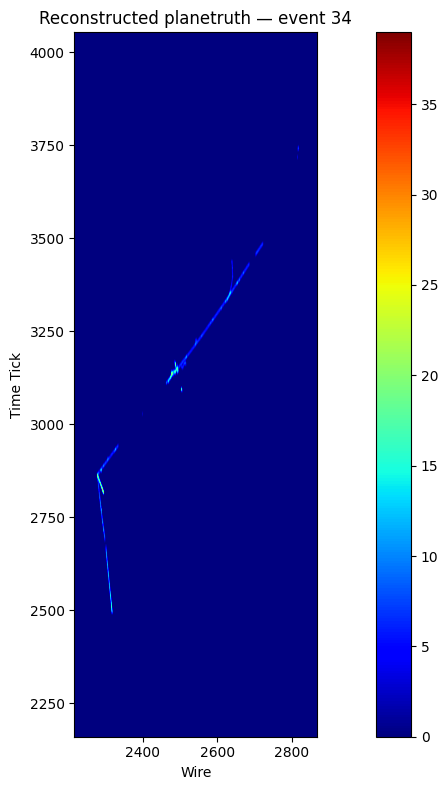

In [13]:
# Read the saved sparse HDF5 and plot a reconstructed event (similar to previous imshow)
import h5py
import numpy as np
import matplotlib.pyplot as plt

h5path = '/nevis/wanaka/data/schung/RAD/ubOpen/planetruth_sparse_00.h5'
with h5py.File(h5path, 'r') as hf:
    coords = hf['coords'][:]
    values = hf['values'][:]
    offsets = hf['offsets'][:]
    bboxes = hf['bboxes'][:]
    shape = tuple(hf.attrs['planetruth_shape'])

# pick first event that has non-zero entries
event_idx = None
for i in range(len(offsets)-1):
    if offsets[i+1] > offsets[i]:
        event_idx = i
        break
if event_idx is None:
    raise RuntimeError('No non-empty events found in ' + h5path)

event_idx = 34  # or set to any valid event index

s = offsets[event_idx]; e = offsets[event_idx+1]
coords_e = coords[s:e].astype(int)
vals_e = values[s:e]
A = np.zeros(shape, dtype=vals_e.dtype)
min_w, max_w, min_t, max_t = bboxes[event_idx]
# coords were saved relative to bbox origin (w0,t0); add offsets to place in full plane
if coords_e.shape[0] > 0:
    wires = coords_e[:,0] + int(min_w)
    times = coords_e[:,1] + int(min_t)
    A[wires, times] = vals_e

# use bbox padding for plotting



pad_w = 50
pad_t = 50
x0 = max(0, min_w - pad_w)
x1 = min(shape[0], max_w + pad_w)
y0 = max(0, min_t - pad_t)
y1 = min(shape[1], max_t + pad_t)

zmax = A.max() if A.size>0 else 1.0
fig, ax = plt.subplots(1,1, figsize=(12,8))
im = ax.imshow(A.T, vmin=0, vmax=zmax, origin='lower', cmap='jet')
ax.set_title(f'Reconstructed planetruth — event {event_idx}')
ax.set_xlabel('Wire')
ax.set_ylabel('Time Tick')
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()